# Día 4: app Streamlit para la tarea `dedo`

## Objetivo

En este cuaderno vais a construir una app sencilla con `Streamlit` para mostrar una predicción sobre imágenes de `dedo`.

La app no tiene por qué ser idéntica para todos los grupos. Lo importante es que conecte un flujo de usuario claro con algún modelo o regla que ya tengáis disponible.

La versión mínima debería permitir:

- subir una imagen;
- procesarla si hace falta;
- obtener una predicción `si` o `no`;
- mostrar una confianza, score o explicación simple.

## Posibles caminos

Podéis reutilizar cualquiera de las soluciones anteriores:

- una heurística clásica del día 1;
- una CNN entrenada en el día 2;
- un clasificador sobre embeddings del día 3.

También podéis decidir si la app:

- usa imagen original;
- muestra además un recorte o panel rectificado;
- da solo una etiqueta;
- o añade una pequeña explicación para ayudar a recolocar la mano.

## Instalación

```bash
pip install streamlit pandas numpy scikit-learn pillow torch torchvision timm opencv-python matplotlib
```

## Importaciones

In [16]:
# Escribe aquí las importaciones necesarias.
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io
import streamlit as st
import cv2
import numpy as np
from PIL import Image

## Definir el flujo de la app

Antes de escribir código, dejad claro qué hará vuestra app.

Una posibilidad razonable es:

1. el usuario sube una imagen;
2. la app la muestra;
3. la app aplica un preprocesado opcional;
4. la app ejecuta el modelo o regla;
5. la app enseña predicción y confianza.

## Reutilizar vuestro pipeline de inferencia

Antes de abrir Streamlit, conviene que tengáis una función de inferencia clara.

Por ejemplo, una función que:

- reciba una imagen;
- aplique el preprocesado necesario;
- devuelva la predicción;
- y, si es posible, una confianza o score.

In [12]:
# Define aquí tu función o pipeline de inferencia.
#Preprocesado

def preprocess_image(img_array: np.ndarray) -> np.ndarray:
    """Redimensiona la imagen a 224x224 y la convierte a BGR si viene en RGB."""
    img = cv2.resize(img_array, (224, 224))
    if img.shape[2] == 4:          # RGBA → BGR
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)
    elif img.shape[2] == 3:        # RGB → BGR (PIL carga en RGB)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    return img


# Máscara

def get_skin_mask(bgr: np.ndarray) -> np.ndarray:
    """
    Devuelve una máscara binaria donde los píxeles de piel son 255.
    Combina rangos en HSV y YCrCb para mayor robustez.
    """
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)

    mask_hsv = cv2.inRange(hsv,
                           np.array([0, 20, 70], dtype=np.uint8),
                           np.array([25, 255, 255], dtype=np.uint8))

    mask_ycrcb = cv2.inRange(ycrcb,
                              np.array([0, 133, 77], dtype=np.uint8),
                              np.array([255, 173, 127], dtype=np.uint8))

    mask = cv2.bitwise_and(mask_hsv, mask_ycrcb)

    # Limpieza morfológica
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    return mask


# Heurística

def predict_dedo(pil_image: Image.Image) -> dict:
    """
    Clasifica si la postura del dedo es correcta.

    Devuelve un dict con:
      - label      : 'sí' | 'no'
      - confidence : float en [0, 1]
      - message    : str con una pista para el usuario
      - mask_img   : np.ndarray con la máscara de piel (para visualización)
    """
    img_array = np.array(pil_image)
    bgr = preprocess_image(img_array)
    mask = get_skin_mask(bgr)

    #  Características 
    total_px   = mask.size
    skin_ratio = np.sum(mask > 0) / total_px   # proporción global de piel

    # Contornos para analizar forma
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    aspect_ratio = 0.0
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / (h + 1e-6)   # < 1 → forma vertical (dedo extendido)

    # ─ Reglas heurísticas 
    #  Un dedo bien posicionado suele tener:
    #    · skin_ratio entre 0.05 y 0.45  (ni demasiado pequeño, ni toda la imagen)
    #    · aspect_ratio < 0.7            (más alto que ancho → dedo vertical)
    skin_ok   = 0.05 < skin_ratio < 0.45
    shape_ok  = aspect_ratio < 0.7

    # Confianza: media ponderada de ambas señales
    skin_score  = 1.0 - abs(skin_ratio - 0.15) / 0.30  # óptimo en ~0.15
    skin_score  = float(np.clip(skin_score, 0, 1))
    shape_score = float(np.clip(1.0 - aspect_ratio, 0, 1))
    confidence  = round(0.5 * skin_score + 0.5 * shape_score, 2)

    label = 'sí' if (skin_ok and shape_ok) else 'no'

    if label == 'no':
        if not skin_ok and skin_ratio < 0.05:
            message = ' No se detecta suficiente piel. Acerca el dedo a la cámara.'
        elif not skin_ok and skin_ratio >= 0.45:
            message = ' Demasiado fondo de piel. Aleja la mano o mejora el fondo.'
        elif not shape_ok:
            message = ' El dedo parece horizontal. Colócalo verticalmente.'
        else:
            message = ' Postura incorrecta. Intenta extender el dedo hacia arriba.'
    else:
        message = '✅ ¡Postura correcta!'

    return {
        'label':      label,
        'confidence': confidence,
        'message':    message,
        'mask_img':   mask,
    }

## Probar una inferencia local dentro de la notebook

Antes de envolver la solución en una app, comprobad que funciona sobre una imagen suelta.

Predicción : no
Confianza  : 0.35
Mensaje    :  El dedo parece horizontal. Colócalo verticalmente.


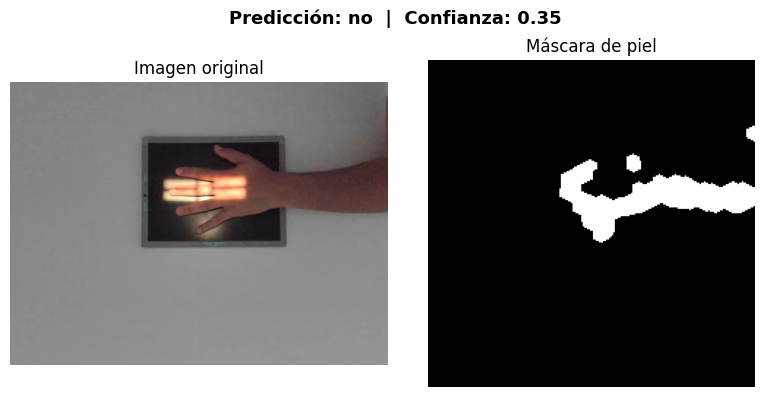

In [13]:
# Prueba aquí una predicción individual.
TEST_IMAGE_PATH = "/home/manel31/Escritorio/cursoIA/dedo/si/img_1776863492105.png"   

test_img = Image.open(TEST_IMAGE_PATH).convert("RGB")
result   = predict_dedo(test_img)

print(f"Predicción : {result['label']}")
print(f"Confianza  : {result['confidence']:.2f}")
print(f"Mensaje    : {result['message']}")

# Visualización rápida
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(test_img)
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(result['mask_img'], cmap='gray')
axes[1].set_title('Máscara de piel')
axes[1].axis('off')

plt.suptitle(f"Predicción: {result['label']}  |  Confianza: {result['confidence']:.2f}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Diseñar la interfaz mínima

Pensad qué elementos visuales vais a necesitar. Por ejemplo:

- título;
- descripción breve;
- cargador de archivos;
- imagen original;
- imagen procesada opcional;
- predicción;
- confianza;
- mensaje de corrección.

No hace falta que sea compleja. Mejor una interfaz simple y clara que una app recargada.

## Crear el script de Streamlit

Podéis escribir la app en un archivo `.py` con `%%writefile`.

Sugerencia: separad bien estas partes dentro del script:

- carga de librerías;
- carga de modelo o artefactos;
- funciones auxiliares;
- interfaz;
- inferencia sobre los archivos subidos.

In [14]:
%%writefile 12_app_dedo_estudiante.py
# Escribe aquí tu app de Streamlit.
# App Streamlit: Detector de postura del dedo
# Heurística OpenCV (detección de piel + análisis de contornos)
# ═══════════════════════════════════════════════════════════════════════════════


#Configuración de página 
st.set_page_config(
    page_title="Detector de postura del dedo",
    page_icon="🫵",
    layout="centered",
)

# 3. Funciones auxiliares

def preprocess_image(img_array: np.ndarray) -> np.ndarray:
    """Redimensiona y convierte a BGR."""
    img = cv2.resize(img_array, (224, 224))
    if img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    return img


def get_skin_mask(bgr: np.ndarray) -> np.ndarray:
    """Máscara binaria de piel (HSV ∩ YCrCb)."""
    hsv   = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)

    mask_hsv   = cv2.inRange(hsv,
                             np.array([0, 20, 70],    dtype=np.uint8),
                             np.array([25, 255, 255], dtype=np.uint8))
    mask_ycrcb = cv2.inRange(ycrcb,
                              np.array([0, 133, 77],   dtype=np.uint8),
                              np.array([255, 173, 127], dtype=np.uint8))

    mask   = cv2.bitwise_and(mask_hsv, mask_ycrcb)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    return mask


@st.cache_data(show_spinner=False)
def predict_dedo(img_bytes: bytes) -> dict:
    """
    Pipeline de inferencia completo.
    Recibe los bytes de la imagen para que st.cache_data pueda hashearlos.
    """
    pil_image = Image.open(img_bytes).convert("RGB")
    img_array = np.array(pil_image)
    bgr  = preprocess_image(img_array)
    mask = get_skin_mask(bgr)

    total_px   = mask.size
    skin_ratio = np.sum(mask > 0) / total_px

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    aspect_ratio = 0.0
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / (h + 1e-6)

    skin_ok  = 0.05 < skin_ratio < 0.45
    shape_ok = aspect_ratio < 0.7

    skin_score  = float(np.clip(1.0 - abs(skin_ratio - 0.15) / 0.30, 0, 1))
    shape_score = float(np.clip(1.0 - aspect_ratio, 0, 1))
    confidence  = round(0.5 * skin_score + 0.5 * shape_score, 2)

    label = 'sí' if (skin_ok and shape_ok) else 'no'

    if label == 'no':
        if skin_ratio < 0.05:
            message = '⚠️ No se detecta suficiente piel. Acerca el dedo a la cámara.'
        elif skin_ratio >= 0.45:
            message = '⚠️ Demasiado fondo de piel. Aleja la mano o mejora el fondo.'
        else:
            message = '⚠️ El dedo parece horizontal. Colócalo verticalmente.'
    else:
        message = '✅ ¡Postura correcta!'

    return {
        'label':       label,
        'confidence':  confidence,
        'message':     message,
        'mask_img':    mask,
        'pil_image':   pil_image,
    }


#Interfaz

st.title("🫵 Detector de postura del dedo")
st.markdown(
    "Sube una imagen de tu mano y la app te dirá si el dedo está correctamente "
    "posicionado. Usa la heurística de detección de piel del **Día 1**."
)
st.divider()

uploaded_file = st.file_uploader(
    "Sube una imagen (JPG, PNG…)",
    type=["jpg", "jpeg", "png", "bmp", "webp"],
)

if uploaded_file is not None:

    # Inferencia
    with st.spinner("Analizando imagen…"):
        result = predict_dedo(uploaded_file)

    # Visualización: dos columnas
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Imagen original")
        st.image(result['pil_image'], use_column_width=True)
    with col2:
        st.subheader("Máscara de piel")
        st.image(result['mask_img'], use_column_width=True, clamp=True)

    st.divider()

    # Resultado 
    label = result['label']
    color = "green" if label == 'sí' else "red"
    emoji = "✅" if label == 'sí' else "❌"

    st.markdown(
        f"### Predicción: :{color}[{emoji} **{label.upper()}**]"
    )

    st.metric(
        label="Confianza",
        value=f"{result['confidence']:.0%}",
    )
    st.progress(result['confidence'])

    st.info(result['message'])

else:
    st.markdown(
        "👆 **Sube una imagen** para comenzar el análisis."
    )

Overwriting 12_app_dedo_estudiante.py


## Ejecutar la app

```bash
streamlit run streamlit_examples/12_app_dedo_estudiante.py
```

## Qué debería mostrar vuestra app

Comprobad si vuestra primera versión ya responde a estas preguntas:

- ¿se entiende para qué sirve la app?
- ¿se ve bien la imagen subida?
- ¿la predicción aparece de forma clara?
- ¿hay alguna pista útil para el usuario cuando la postura es incorrecta?

## Mejoras opcionales de interfaz

Si termináis la versión mínima, podéis probar alguna ampliación:

- mostrar original y recorte lado a lado;
- enseñar probabilidades por clase;
- permitir varias imágenes a la vez;
- cachear el modelo para no recargarlo continuamente;
- mostrar ejemplos de errores frecuentes.

In [15]:
# Añade aquí mejoras opcionales si llegas a ellas.

## Extensión opcional: webcam y overlay

Si vuestro grupo va rápido, podéis pensar una versión más ambiciosa:

- capturar imagen desde webcam;
- dibujar una guía visual;
- mostrar una indicación de cómo recolocar la mano.

No hace falta implementarlo completo. También vale dejarlo diseñado como siguiente paso.

## Conclusiones

Escribid aquí unas conclusiones breves:

- qué solución habéis integrado;
- qué partes de la app funcionan ya;
- qué mejoraríais para convertirla en una demo más robusta.